In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from nba_api.stats.endpoints import leaguedashplayerstats
import pandas as pd

stats = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25')
df = stats.get_data_frames()[0]

In [36]:
features = ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'FG3A', 'FG3_PCT']

df_clean = df[df['MIN'] > 15].copy()
df_clean = df_clean.dropna(subset=features)

X = StandardScaler().fit_transform(df_clean[features])

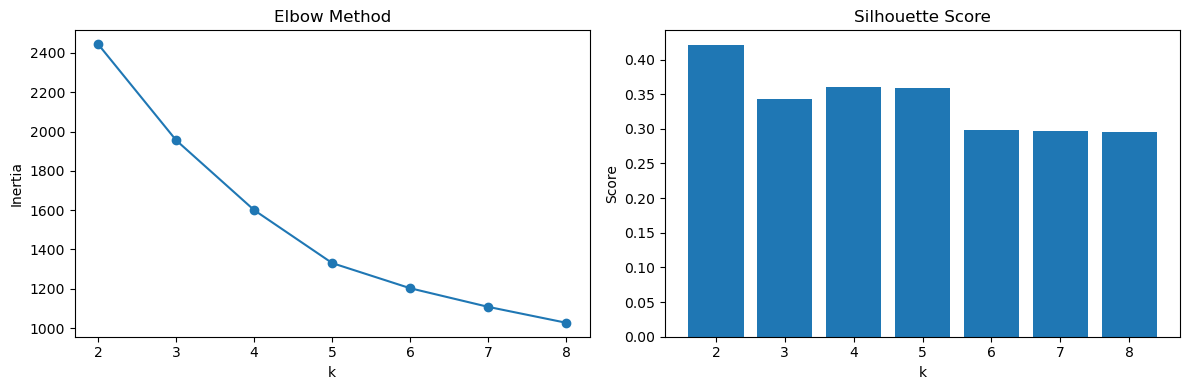

In [37]:
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')

ax2.bar(list(K_range), silhouettes)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k')
ax2.set_ylabel('Score')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# adjust k here based on your elbow plot
k = 5

km = KMeans(n_clusters=k, n_init=20, random_state=42)
df_clean['cluster'] = km.fit_predict(X)

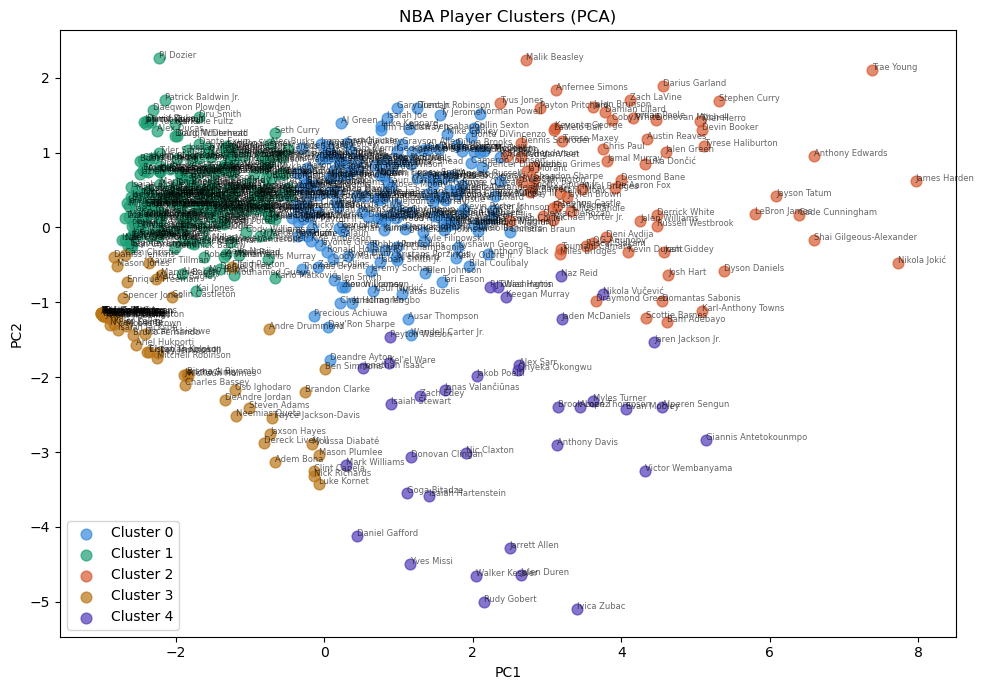

In [39]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
df_clean['pc1'] = coords[:, 0]
df_clean['pc2'] = coords[:, 1]

colors = ['#378add', '#1d9e75', '#d85a30', '#ba7517', '#533ab7']

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(k):
    mask = df_clean['cluster'] == c
    ax.scatter(df_clean.loc[mask, 'pc1'], df_clean.loc[mask, 'pc2'],
               label=f'Cluster {c}', color=colors[c], alpha=0.7, s=60)
    for _, row in df_clean[mask].iterrows():
        ax.annotate(row['PLAYER_NAME'], (row['pc1'], row['pc2']),
                    fontsize=6, alpha=0.6)

ax.legend()
ax.set_title('NBA Player Clusters (PCA)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
for c in range(k):
    print(f"\n--- Cluster {c} ---")
    print(df_clean[df_clean['cluster'] == c]['PLAYER_NAME'].values)


--- Cluster 0 ---
['AJ Green' 'Aaron Gordon' 'Aaron Nesmith' 'Aaron Wiggins' 'Al Horford'
 'Alex Caruso' 'Amir Coffey' 'Andrew Nembhard' 'Andrew Wiggins'
 'Anthony Black' 'Ausar Thompson' 'Ayo Dosunmu' 'Ben Sheppard'
 'Bennedict Mathurin' 'Bilal Coulibaly' 'Bobby Portis' 'Bogdan Bogdanović'
 'Bradley Beal' 'Brandin Podziemski' 'Brandon Boston' 'Brandon Miller'
 'Brice Sensabaugh' 'Buddy Hield' 'CJ McCollum' 'Caleb Martin'
 'Cameron Johnson' 'Cameron Payne' 'Caris LeVert' 'Cason Wallace'
 'Chet Holmgren' 'Chris Boucher' 'Christian Braun' 'Cody Martin'
 'Cole Anthony' 'Collin Sexton' 'Corey Kispert' "D'Angelo Russell"
 'Dalano Banton' 'Dalton Knecht' 'Davion Mitchell' "Day'Ron Sharpe"
 "De'Andre Hunter" 'Dean Wade' 'Deandre Ayton' 'Dejounte Murray'
 'Derrick Jones Jr.' 'Devin Vassell' 'Dillon Brooks' 'Donte DiVincenzo'
 'Dorian Finney-Smith' 'Duncan Robinson' 'Gabe Vincent' 'Gary Payton II'
 'Gary Trent Jr.' 'Georges Niang' 'Gradey Dick' 'Grayson Allen'
 'Guerschon Yabusele' 'Harrison B

In [41]:
centroids = df_clean.groupby('cluster')[features].mean().round(2)
print(centroids)

             PTS     REB     AST    STL    BLK     TOV    FG3A  FG3_PCT
cluster                                                                
0         655.01  239.28  139.25  51.57  23.77   72.14  254.78     0.36
1         153.61   66.69   36.78  14.59   7.47   19.66   61.02     0.33
2        1374.28  377.04  381.13  80.82  31.10  171.63  441.13     0.36
3         126.26  119.06   30.00  11.13  15.34   20.18    4.90     0.03
4         931.06  559.81  160.14  56.22  90.28  103.00  149.67     0.24


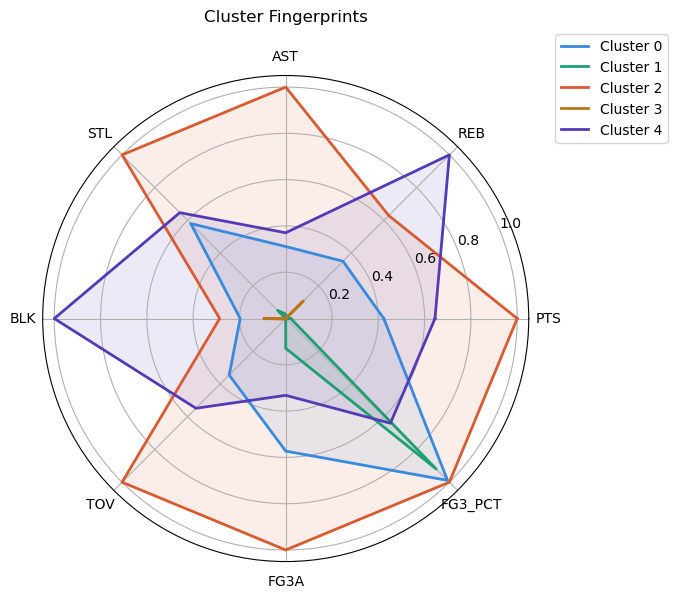

In [42]:
centroid_vals = df_clean.groupby('cluster')[features].mean()
centroid_norm = (centroid_vals - centroid_vals.min()) / (centroid_vals.max() - centroid_vals.min())

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for c in range(k):
    vals = centroid_norm.loc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[c], linewidth=2, label=f'Cluster {c}')
    ax.fill(angles, vals, color=colors[c], alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), features)
ax.set_title('Cluster Fingerprints', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()